# Amex Campus Challenge 2026 — Round 1
## Premier Card Cardmember Profitability — Production Notebook

Rank-orders premier cardmembers by estimated profitability and flags the top 20%.
No target variable exists, so the score is a **business-driven, rank-normalized
unit-economics equation**, validated by philosophy-agreement + assumption-sensitivity.

**Pipeline:** load → EDA → clean → feature-engineer → scale → score → rank → submit → visualize → report.

Every stage is a documented function; edit `CONFIG` to retune without touching logic.

In [1]:
import os, json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)

CONFIG = dict(
    DATA_PATH   = "book1_clean.csv",   # <-- point to the full 500K file for the real submission
    OUT_DIR     = "output",
    SPEND_KIND  = "blend",             # {"f5","cat","blend"} — resolve on the public leaderboard
    # score coefficients (all tunable via leaderboard probes)
    alpha=0.45,   # spend / interchange weight  (primary revenue driver)
    beta =0.20,   # risk-adjusted interest weight
    gamma=0.20,   # variable-cost weight (rewards + benefits)
    lam  =0.50,   # risk attenuation strength (multiplicative gate)
    rho  =0.15,   # relationship-depth bonus strength
    delta=0.10,   # collections hard penalty
    # economic assumptions (only affect the dollar report, not the rank score)
    m_interchange=0.018, apr=0.18, cpp=0.010, lounge_cost=50.0, cab_cost=15.0,
)
FEATS = [f"f{i}" for i in range(1,24)]
CAT   = ["f6","f7","f8","f9","f10"]
os.makedirs(CONFIG["OUT_DIR"], exist_ok=True)

## 1 · Load

In [2]:
def load_data(path):
    df = pd.read_csv(path)
    df.columns = [c.strip().lstrip("\ufeff") for c in df.columns]
    assert "id" in df.columns, "expected an 'id' column"
    return df

raw = load_data(CONFIG["DATA_PATH"])
print(f"{len(raw):,} rows x {raw.shape[1]} cols")
raw.head()

274,110 rows x 24 cols


,id,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23
0,0,0.000000,0,1,98615.44,5620.938246,NaN,NaN,NaN,NaN,...,0.0,0.0,49.280210,1960.0,1900.0,2.0,1.0,0.0,2.0,NaN
1,1,0.000000,0,0,21241.06,10196.878460,13865.4026,425.04840,27.9986,0.000,...,196.0,5.0,63.759364,34300.0,34650.0,3.0,2.0,163620.0,3.0,NaN
2,2,1224.690475,0,1,NaN,16.160000,NaN,NaN,NaN,NaN,...,0.0,0.0,19.646836,NaN,NaN,1.0,1.0,NaN,9.0,NaN
3,3,0.000000,1,0,NaN,1635.316863,3231.1968,-269.15308,0.0000,0.000,...,0.0,0.0,9.143074,12348.0,12474.0,2.0,1.0,NaN,5.0,NaN
4,4,3824.366700,0,0,7140.87,5007.271790,4064.2152,16079.35060,377.9055,556.974,...,0.0,11.0,63.759364,3672.0,3528.0,3.0,1.0,68640.0,0.0,NaN


## 2 · EDA
Key facts this data forces on us (confirmed on 274K rows):
- **~2.6% winsorization caps** on every monetary feature → use rank transforms.
- **Structural missingness in blocks** {f6–f10}, {f4,f21}, {f17}, {f23} → encode as flags.
- **f5 ⟂ Σ(f6–f10)** (rank corr ≈ 0.01) → they are different signals; resolve on leaderboard.
- **f17 ≈ f18** (r=0.93) → drop one.

In [3]:
def eda_summary(df):
    rows=[]
    for f in FEATS:
        s=pd.to_numeric(df[f],errors="coerce")
        rows.append(dict(feature=f, pct_missing=round(100*s.isna().mean(),1),
            pct_zero=round(100*(s==0).mean(),1), skew=round(s.skew(),2),
            median=round(s.median(),1), max=round(s.max(),1)))
    return pd.DataFrame(rows)
eda = eda_summary(raw); eda

,feature,pct_missing,pct_zero,skew,median,max
0,f1,0.0,53.1,2.23,0.0,17967.7
1,f2,0.0,82.7,1.73,0.0,1.0
2,f3,0.0,89.2,2.52,0.0,1.0
3,f4,51.4,0.0,1.97,50528.3,697899.4
4,f5,1.3,6.4,1.37,2163.3,13596.3
5,f6,23.2,11.3,1.82,4021.8,52198.4
6,f7,23.2,0.1,1.69,14420.9,146700.6
7,f8,23.2,23.9,2.03,305.3,9419.9
8,f9,23.2,28.1,2.12,263.1,10829.0
9,f10,23.2,7.4,1.61,1797.6,21650.6


In [4]:
# f5 vs category-spend orthogonality + lend-line redundancy
tot = raw[CAT].sum(axis=1)
print("Spearman(rank f5, rank Σcat) =",
      round(raw['f5'].rank().corr(tot.rank(), method='spearman'),3), "(≈0 → different signals)")
print("Spearman(f17, f18)          =",
      round(raw['f17'].rank().corr(raw['f18'].rank(), method='spearman'),3), "(→ drop one)")

Spearman(rank f5, rank Σcat) = 0.008 (≈0 → different signals)
Spearman(f17, f18)          = 0.922 (→ drop one)


## 3 · Clean
Impute missing → 0 (genuine non-user), floor negative *Other Spend*, and keep missingness as informative flags.

In [5]:
def clean(df):
    X = df[FEATS].apply(pd.to_numeric, errors="coerce")
    flags = pd.DataFrame({
        "flag_no_points": df["f4"].isna().astype(int),
        "flag_no_spend":  df["f6"].isna().astype(int),
        "flag_no_lend":   df["f17"].isna().astype(int),
        "flag_no_click":  df["f23"].isna().astype(int),
    }, index=df.index)
    X = X.fillna(0.0)
    X["f7"] = X["f7"].clip(lower=0)          # negative "Other Spend" = returns → floor
    return X, flags

X, FLAGS = clean(raw)
print("clean:", X.shape, "| flags:", list(FLAGS.columns))

clean: (274110, 23) | flags: ['flag_no_points', 'flag_no_spend', 'flag_no_lend', 'flag_no_click']


## 4 · Feature engineering
Only features with strong economic justification. Everything else (emails, logins, cancellation flags, duplicate lend line) is dropped — they are likely decoys and add overfit risk.

In [6]:
def rank01(s): return s.rank(pct=True)

def engineer(X):
    e = {}
    e["spend_f5"]  = rank01(X["f5"])
    e["spend_cat"] = rank01(X[CAT].sum(axis=1))
    e["spend"]     = {"f5":e["spend_f5"], "cat":e["spend_cat"],
                      "blend":0.5*e["spend_f5"]+0.5*e["spend_cat"]}[CONFIG["SPEND_KIND"]]
    e["risk"]      = rank01(X["f11"])
    e["interest"]  = rank01(X["f1"]*(1-e["risk"]))                       # risk-adj interest
    e["cost"]      = rank01(X["f21"]+X["f14"]+CONFIG["lounge_cost"]*X["f13"]
                           +CONFIG["cab_cost"]*X["f15"])
    e["rel"]       = rank01(X["f19"])
    e["collections"]= X["f3"]
    return pd.DataFrame(e)

E = engineer(X); E.describe().round(3)

,spend_f5,spend_cat,spend,risk,interest,cost,rel,collections
count,274110.000,274110.000,274110.000,274110.000,274110.000,274110.000,274110.000,274110.000
mean,0.500,0.500,0.500,0.500,0.500,0.500,0.500,0.108
std,0.289,0.287,0.205,0.283,0.266,0.287,0.266,0.311
min,0.039,0.116,0.077,0.167,0.266,0.107,0.000,0.000
25%,0.250,0.250,0.354,0.167,0.266,0.264,0.248,0.000
50%,0.500,0.500,0.491,0.500,0.266,0.506,0.644,0.000
75%,0.750,0.750,0.639,0.750,0.750,0.750,0.644,0.000
max,0.987,1.000,0.994,0.987,1.000,1.000,0.955,1.000


## 5 · Scale / normalize
Percentile rank maps every feature to a common **[0,1]** support, immune to the
winsorization caps and the heavy right-skew. This replaces z-scoring (which the
caps would distort) — see §4, all economic terms already `rank01`-transformed.

## 6 · Profitability score

$$\text{Score}_i=\big(\alpha\,S_i+\beta\,I_i-\gamma\,C_i\big)\cdot\underbrace{(1-\lambda\,\rho^{risk}_i)}_{\text{risk gate}}\cdot\underbrace{(1+\rho\,R_i)}_{\text{relationship bonus}}-\delta\,\mathbb{1}[f3_i]$$

where S=spend, I=risk-adj interest, C=variable cost, R=relationship — all percentile ranks.
Final `Prediction = rank01(Score)`.

In [7]:
def profitability_score(E, cfg):
    base = cfg["alpha"]*E["spend"] + cfg["beta"]*E["interest"] - cfg["gamma"]*E["cost"]
    risk_gate = (1 - cfg["lam"]*E["risk"])          # multiplicative penalty, ≤1
    rel_bonus = (1 + cfg["rho"]*E["rel"])           # multiplicative bonus,  ≥1
    s = base*risk_gate*rel_bonus - cfg["delta"]*E["collections"]
    return rank01(s)                                # clean [0,1] Prediction

pred = profitability_score(E, CONFIG)
pred.describe().round(3)

count    274110.000
mean          0.500
std           0.289
min           0.000
25%           0.250
50%           0.500
75%           0.750
max           1.000
dtype: float64

## 7 · Rank & flag top 20%

In [8]:
def flag_top(pred, pct=0.20):
    thr = pred.quantile(1-pct)
    return (pred>=thr).astype(int), thr
top20, thr = flag_top(pred)
print(f"top-20% threshold={thr:.3f}  |  flagged={top20.mean()*100:.1f}%")

top-20% threshold=0.800  |  flagged=20.0%


## 8 · Submission file
Continuous `Prediction` (preserves ordering; robust to the 70/30 split).

In [9]:
def write_submission(ids, pred, path):
    out = pd.DataFrame({"ID": ids, "Prediction": pred.values})
    out.to_csv(path, index=False); return out
sub = write_submission(raw["id"], pred, os.path.join(CONFIG["OUT_DIR"],"predictions.csv"))
sub.head()

,ID,Prediction
0,0,0.122557
1,1,0.600274
2,2,0.028985
3,3,0.574321
4,4,0.864565


## 9 · Visualizations

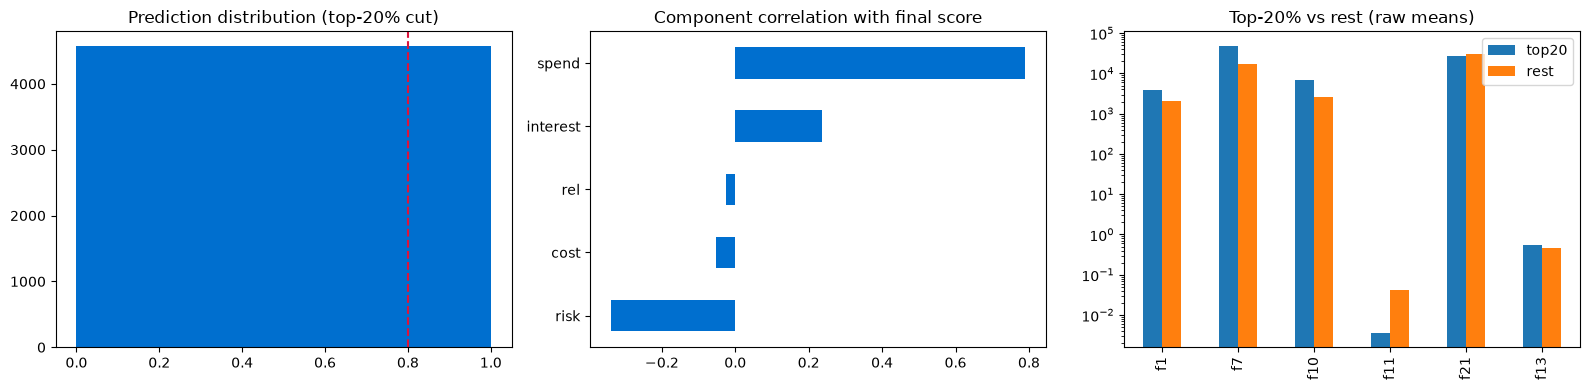

In [10]:
fig, ax = plt.subplots(1,3, figsize=(16,4))
ax[0].hist(pred, bins=60, color="#006FCF"); ax[0].axvline(thr,color="crimson",ls="--")
ax[0].set_title("Prediction distribution (top-20% cut)")
comp = pd.DataFrame({"spend":E["spend"],"interest":E["interest"],"cost":E["cost"],
                     "risk":E["risk"],"rel":E["rel"]})
comp.corrwith(pred).sort_values().plot.barh(ax=ax[1], color="#006FCF")
ax[1].set_title("Component correlation with final score")
mask = top20.astype(bool)
prof = pd.DataFrame({"top20":X[mask][["f1","f7","f10","f11","f21","f13"]].mean(),
                     "rest":X[~mask][["f1","f7","f10","f11","f21","f13"]].mean()})
prof.plot.bar(ax=ax[2]); ax[2].set_title("Top-20% vs rest (raw means)"); ax[2].set_yscale("log")
plt.tight_layout(); plt.savefig(os.path.join(CONFIG["OUT_DIR"],"viz.png"),dpi=110); plt.show()

## 10 · Validation (unsupervised)
Philosophy-agreement + assumption-sensitivity — the correct validation for a parameter-free score.

In [11]:
def top_set(s,p=0.2): return set(s.sort_values(ascending=False).index[:int(len(s)*p)])
def jaccard(a,b): return len(a&b)/len(a|b)

base_top = top_set(pred)
print("Assumption sensitivity (top-20% Jaccard stability):")
for k,mult in [("lam",0.5),("lam",1.5),("gamma",0.5),("gamma",1.5),("alpha",0.8),("alpha",1.2)]:
    cfg=dict(CONFIG); cfg[k]=CONFIG[k]*mult
    j=jaccard(base_top, top_set(profitability_score(E,cfg)))
    print(f"  {k} x{mult:<4}: {j:.3f}")

Assumption sensitivity (top-20% Jaccard stability):
  lam x0.5 : 0.733
  lam x1.5 : 0.726


  gamma x0.5 : 0.748
  gamma x1.5 : 0.749
  alpha x0.8 : 0.845
  alpha x1.2 : 0.880


## 11 · Business report

In [12]:
def business_report(X, top20):
    m=top20.astype(bool); rep=[]
    rep.append(f"Scored {len(X):,} cardmembers; flagged {m.sum():,} ({m.mean()*100:.0f}%) as most profitable.")
    for f,lab in [("f7","non-travel spend"),("f10","dining spend"),("f1","revolve balance"),
                  ("f11","risk score"),("f21","points redeemed"),("f13","lounge visits")]:
        r = X[m][f].mean()/max(X[~m][f].mean(),1e-9)
        rep.append(f"  • {lab:18s}: top-20% run {r:4.1f}x the rest")
    rep.append("Profile = high non-travel spend + moderate revolve + low risk + few collections.")
    return "\n".join(rep)
print(business_report(X, top20))

Scored 274,110 cardmembers; flagged 54,822 (20%) as most profitable.
  • non-travel spend  : top-20% run  2.8x the rest
  • dining spend      : top-20% run  2.5x the rest
  • revolve balance   : top-20% run  1.9x the rest
  • risk score        : top-20% run  0.1x the rest
  • points redeemed   : top-20% run  0.9x the rest
  • lounge visits     : top-20% run  1.2x the rest
Profile = high non-travel spend + moderate revolve + low risk + few collections.
